=== Ventes par produit ===
     produit chiffre_affaires
0  Produit A         17500.00
1  Produit B         15825.00
2  Produit C         11500.00

=== Ventes par région ===
  region chiffre_affaires
0    Sud         24100.00
1   Nord         20725.00


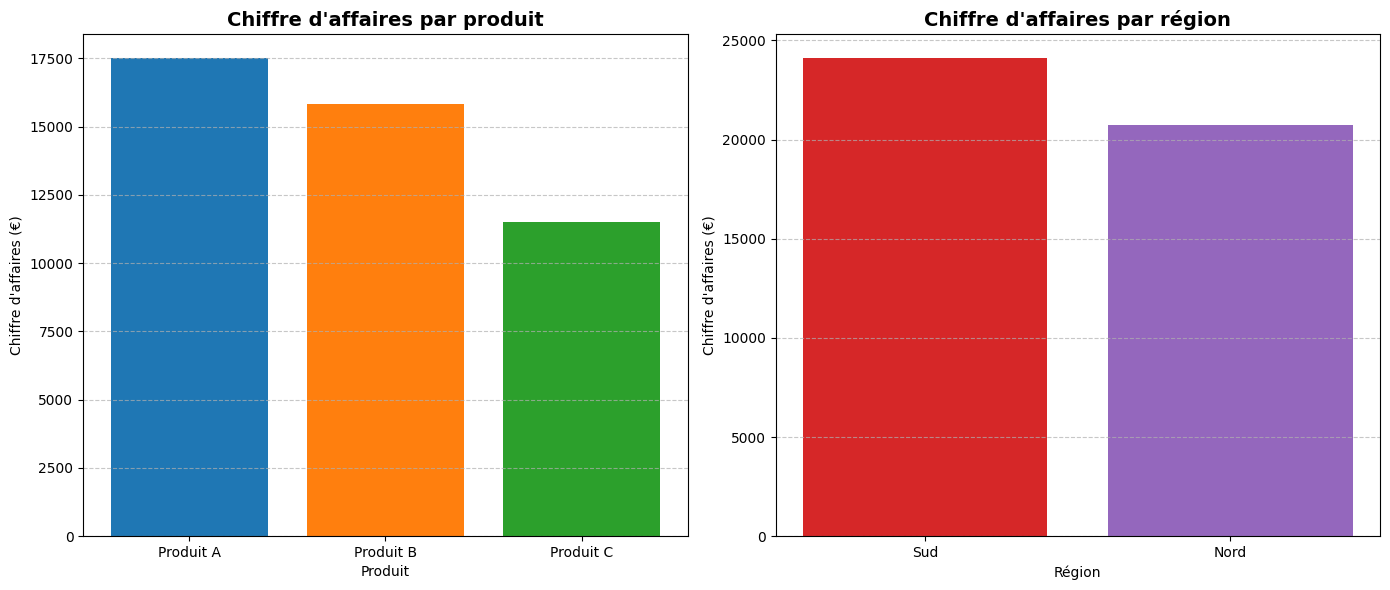

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ====================== CONNEXION SQLITE EN MÉMOIRE ======================
conn = sqlite3.connect(':memory:')

# ====================== CRÉATION DE LA TABLE (avec DROP pour éviter les erreurs) ======================
sql_script = """
DROP TABLE IF EXISTS ventes;

CREATE TABLE ventes (c1 TEXT, c2 TEXT, c3 TEXT, c4 TEXT, c5 TEXT);

INSERT INTO ventes (c1,c2,c3,c4,c5) VALUES
('date','produit','prix','qte','region'),
('2022-01-01','Produit A','10','100','Nord'),
('2022-01-02','Produit B','15','50','Nord'),
('2022-01-02','Produit A','10','75','Sud'),
('2022-01-03','Produit C','20','30','Nord'),
('2022-01-03','Produit A','10','150','Sud'),
('2022-01-04','Produit B','15','75','Nord'),
('2022-01-04','Produit C','20','50','Sud'),
('2022-01-05','Produit A','10','125','Nord'),
('2022-01-05','Produit B','15','100','Sud'),
('2022-01-06','Produit C','20','25','Nord'),
('2022-01-06','Produit A','10','100','Sud'),
('2022-01-07','Produit B','15','60','Nord'),
('2022-01-07','Produit C','20','40','Sud'),
('2022-01-08','Produit A','10','80','Nord'),
('2022-01-08','Produit B','15','90','Sud'),
('2022-01-09','Produit C','20','35','Nord'),
('2022-01-09','Produit A','10','120','Sud'),
('2022-01-10','Produit B','15','70','Nord'),
('2022-01-10','Produit C','20','60','Sud'),
('2022-01-11','Produit A','10','150','Nord'),
('2022-01-11','Produit B','15','80','Sud'),
('2022-01-12','Produit C','20','40','Nord'),
('2022-01-12','Produit A','10','200','Sud'),
('2022-01-13','Produit B','15','100','Nord'),
('2022-01-13','Produit C','20','60','Sud'),
('2022-01-14','Produit A','10','120','Nord'),
('2022-01-14','Produit B','15','50','Sud'),
('2022-01-15','Produit C','20','30','Nord'),
('2022-01-15','Produit A','10','75','Sud'),
('2022-01-16','Produit B','15','90','Nord'),
('2022-01-16','Produit C','20','75','Sud'),
('2022-01-17','Produit A','10','180','Nord'),
('2022-01-17','Produit B','15','100','Sud'),
('2022-01-18','Produit C','20','50','Nord'),
('2022-01-18','Produit A','10','150','Sud'),
('2022-01-19','Produit B','15','70','Nord'),
('2022-01-19','Produit C','20','80','Sud'),
('2022-01-20','Produit A','10','125','Nord'),
('2022-01-20','Produit B','15','120','Sud');
"""

conn.executescript(sql_script)

# ====================== CALCUL DES VENTES (par produit et par région) ======================
df_produit = pd.read_sql_query("""
    SELECT c2 AS produit,
           printf('%.2f', SUM(CAST(c3 AS REAL) * CAST(c4 AS REAL))) AS chiffre_affaires
    FROM ventes
    WHERE c1 != 'date'
    GROUP BY c2
    ORDER BY chiffre_affaires DESC;
""", conn)

df_region = pd.read_sql_query("""
    SELECT c5 AS region,
           printf('%.2f', SUM(CAST(c3 AS REAL) * CAST(c4 AS REAL))) AS chiffre_affaires
    FROM ventes
    WHERE c1 != 'date'
    GROUP BY c5
    ORDER BY chiffre_affaires DESC;
""", conn)

# ====================== AFFICHAGE DES RÉSULTATS ======================
print("=== Ventes par produit ===")
print(df_produit)
print("\n=== Ventes par région ===")
print(df_region)

# ====================== LES 2 GRAPHIQUES ======================
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : Par produit
axs[0].bar(df_produit['produit'], df_produit['chiffre_affaires'].astype(float),
           color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axs[0].set_title('Chiffre d\'affaires par produit', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Produit')
axs[0].set_ylabel('Chiffre d\'affaires (€)')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Par région
axs[1].bar(df_region['region'], df_region['chiffre_affaires'].astype(float),
           color=['#d62728', '#9467bd'])
axs[1].set_title('Chiffre d\'affaires par région', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Région')
axs[1].set_ylabel('Chiffre d\'affaires (€)')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()